# COSTOS FC


## ANALISIS DE PORTAFOLIO MEDIANTE EL METODO DE FRONTERA EFICIENTE


## PARA LAS EMPRESAS Google (GOOG), Apple (AAPL) y Bank of America (BAC).

In [1]:
pip install yfinance

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

In [7]:
tickers = ["GOOG", "AAPL", "BAC"]

# Descargamos precios ajustados de los últimos 3 años
data = yf.download(tickers, start="2022-01-01", end="2025-01-01")['Close']

# Mostramos las primeras filas
print("Datos descargados:")
print(data.head(25))

/tmp/ipython-input-3741247063.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  3 of 3 completed

Datos descargados:
Ticker            AAPL        BAC        GOOG
Date                                         
2022-01-03  178.443161  41.931011  144.088455
2022-01-04  176.178391  43.574482  143.434952
2022-01-05  171.492081  42.839005  136.717896
2022-01-06  168.629288  43.701607  136.616119
2022-01-07  168.795959  44.654995  136.073303
2022-01-10  168.815552  44.427994  137.632156
2022-01-11  171.648956  44.682228  139.065826
2022-01-12  172.090103  44.364433  140.685242
2022-01-13  168.815552  44.273632  138.185364
2022-01-14  169.678345  43.501839  138.836395
2022-01-18  166.472397  42.003651  135.364151
2022-01-19  162.972382  42.167091  134.729996
2022-01-20  161.286072  41.540585  132.599091
2022-01-21  159.227234  40.786942  129.207794
2022-01-24  158.452698  40.450993  129.485886
2022-01-25  156.648788  41.250031  125.874107
2022-01-26  156.560547  41.676785  128.361588
2022-01-27  156.099762  41.286350  128.243393
2022-01-28  166.992020  41.649540  132.383575
2022-01-31  171

In [8]:
# Cálculo de retornos logarítmicos diarios
returns = np.log(data / data.shift(1)).dropna()

# Promedios y covarianzas anualizados (252 días de trading al año)
trading_days = 252
mean_returns = returns.mean() * trading_days
cov_matrix = returns.cov() * trading_days

print("\nRendimientos esperados anualizados:")
print(mean_returns.round(4))


Rendimientos esperados anualizados:
Ticker
AAPL    0.1124
BAC     0.0098
GOOG    0.0924
dtype: float64


In [35]:

# PASO 5: RESTRICCIONES DEL PROBLEMA

import numpy as np

# num_assets: número de activos que estás usando
num_assets = len(tickers)

# args: argumentos para funciones de optimización
args = (mean_returns, cov_matrix)

# Restricción: la suma de los pesos debe ser 1 (todo el capital invertido)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Límite de pesos: 0 <= w <= 1  (no se permiten posiciones cortas)
bounds = tuple((0, 1) for _ in range(num_assets))

# Peso inicial: distribución igual entre todos los activos
initial_guess = num_assets * [1. / num_assets]

# Mostrar resultados base
print("Activos:", tickers)
print("Número de activos:", num_assets)
print("Pesos iniciales:", initial_guess)
print("Restricciones y límites configurados correctamente ✅")


Activos: ['GOOG', 'AAPL', 'BAC']
Número de activos: 3
Pesos iniciales: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Restricciones y límites configurados correctamente ✅


In [36]:
# ==========================================================
# PASO 6: OPTIMIZACIÓN DE PORTAFOLIOS
# ==========================================================
rf = 0.02  # tasa libre de riesgo (2%)

# Portafolio de Máxima Sharpe
max_sharpe = minimize(neg_sharpe_ratio, initial_guess, args=args + (rf,),
                      method='SLSQP', bounds=bounds, constraints=constraints)

# Portafolio de Mínima Varianza
min_var = minimize(minimize_volatility, initial_guess, args=args,
                   method='SLSQP', bounds=bounds, constraints=constraints)

# Resultados de rendimiento y riesgo
ret_sharpe, vol_sharpe = portfolio_performance(max_sharpe.x, mean_returns, cov_matrix)
ret_min, vol_min = portfolio_performance(min_var.x, mean_returns, cov_matrix)

print("\nPesos óptimos — Máxima Sharpe:")
print(pd.Series(max_sharpe.x, index=tickers).round(4))
print("\nPesos óptimos — Mínima Varianza:")
print(pd.Series(min_var.x, index=tickers).round(4))



Pesos óptimos — Máxima Sharpe:
GOOG    0.9692
AAPL    0.0000
BAC     0.0308
dtype: float64

Pesos óptimos — Mínima Varianza:
GOOG    0.4258
AAPL    0.4615
BAC     0.1127
dtype: float64


In [39]:
# Número de simulaciones
num_portfolios = 5000

# Listas para guardar resultados
results = np.zeros((3, num_portfolios))
weights_record = []

# Tasa libre de riesgo (puedes ajustarla)
risk_free_rate = 0.04  # 4%

for i in range(num_portfolios):
    # Generar pesos aleatorios que sumen 1
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    # Guardar los pesos
    weights_record.append(weights)

    # Calcular rendimiento esperado del portafolio
    portfolio_return = np.sum(mean_returns * weights) * 252  # anualizado

    # Calcular riesgo (desviación estándar)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))

    # Calcular ratio de Sharpe
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev

    # Guardar resultados
    results[0, i] = portfolio_std_dev
    results[1, i] = portfolio_return
    results[2, i] = sharpe_ratio

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results.T, columns=['Riesgo', 'Retorno', 'Sharpe'])
weights_df = pd.DataFrame(weights_record, columns=tickers)

# Identificar el portafolio con mejor ratio Sharpe
max_sharpe_idx = results_df['Sharpe'].idxmax()
max_sharpe_port = results_df.loc[max_sharpe_idx]
best_weights = weights_df.loc[max_sharpe_idx]

# Mostrar resultados del mejor portafolio
print("==========================================")
print("📊 PORTAFOLIO CON MEJOR RATIO DE SHARPE")
print("==========================================")
print(f"Retorno esperado anual: {max_sharpe_port['Retorno']:.2f}")
print(f"Riesgo (desviación estándar): {max_sharpe_port['Riesgo']:.2f}")
print(f"Ratio de Sharpe: {max_sharpe_port['Sharpe']:.2f}")
print("\nPesos óptimos:")
print(best_weights)

📊 PORTAFOLIO CON MEJOR RATIO DE SHARPE
Retorno esperado anual: 28.27
Riesgo (desviación estándar): 4.29
Ratio de Sharpe: 6.58

Pesos óptimos:
GOOG    0.996917
AAPL    0.001396
BAC     0.001687
Name: 2430, dtype: float64


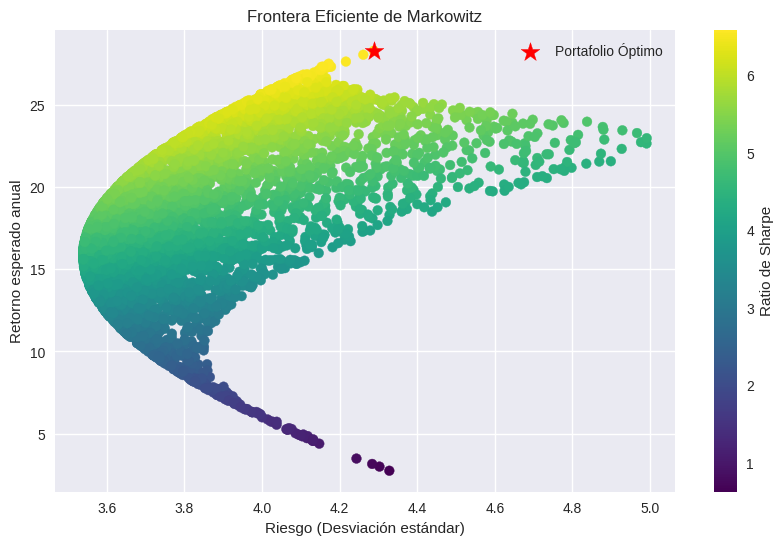

In [40]:
# Graficar frontera eficiente
plt.figure(figsize=(10,6))
plt.scatter(results_df['Riesgo'], results_df['Retorno'], c=results_df['Sharpe'], cmap='viridis')
plt.colorbar(label='Ratio de Sharpe')
plt.scatter(max_sharpe_port['Riesgo'], max_sharpe_port['Retorno'], color='red', marker='*', s=200, label='Portafolio Óptimo')
plt.title('Frontera Eficiente de Markowitz')
plt.xlabel('Riesgo (Desviación estándar)')
plt.ylabel('Retorno esperado anual')
plt.legend()
plt.grid(True)
plt.show()